

<font color=#009afa size=50>DAT5004-Big Data Management Systems</font>

<font size=50 color=#00c382>Task One - Web Scraping Task</font><br>
<font size=35>Extracting Movie Information from FilmCrave.com</font>

**Assessment Code:** PRAC1 (Task 1)

**Author:** Tom Rowan, ST20285213

**Course:** DAT5004_S2_24

**Course Tutor:** Dr. Sandeep Singh Sengar

<p>

> FilmCrave (https://www.filmcrave.com/list_top_movie.php) is a website where people share their favourite
movies, reviews, and ratings. It has a huge collection of films, complete with rankings, genres, and other details.

> The goal of this project is to gather information on over 1,000 movies from this site. The data we want includes the
Year of Release, Overall Rating, Language, Genre, MPAA Rating (like PG or R), Director, Actors, and a short Plot
summary.

> To do this, you’ll use Python. A tool called BeautifulSoup will help you read and understand the webpage's layout
to pull out the data we need. Another tool, Requests, will help you connect to the website and fetch its content.
Once you have the data, you’ll use Pandas to organise it neatly into a table format, and then save it as a CSV file.
After gathering the data, you’ll clean it up, fix any missing or incorrect values, and make sure everything is
consistent. Then, you’ll analyse it. you’ll create visual charts, like bar graphs showing popular genres or line graphs
tracking how movie ratings have changed over time, using tools like Matplotlib and Seaborn. This project will
teach valuable skills in web scraping, data organisation, and analysis.

## Install and Import Required Libraries

In [23]:
%pip install -r requirements.txt

Note: you may need to restart the kernel to use updated packages.


In [1]:
# BeautifulSoup and Requests
from bs4 import BeautifulSoup
import requests

# Pandas and numpy
import pandas as pd
import numpy as np

# Matplot Lib
import matplotlib.pyplot as plt
from matplotlib import colormaps
from matplotlib.pyplot import figure
%matplotlib inline

# Seaborn Graphs
import seaborn as sns

# Tabulate
from tabulate import tabulate

# Pillow
from PIL import Image

# Wordcloud
from wordcloud import WordCloud, STOPWORDS, ImageColorGenerator

# Do not print warnings!
import warnings
warnings.filterwarnings('ignore')

### Site Friendly Behaviour

Scraping a large amount of data from a website like FilmCrave.com may be seen as unfriendly behaviour by the site admins. Continually scraping large amounts of data from the site could result in a source IP address being banned. 

 

There are several reasons for this. One is because there is a financial implication each time the website retrieves data from the database, generates a page and delivers the data to a browser. CPU processing time and bandwidth must be paid for, particularly if the website is hosted within a cloud provider such as Microsoft Azure, Amazon AWS or Google Compute Platform. Furthermore, the data belongs to the site and there may be a perception that scraping this data is equivalent to theft. 


To minimise the impact against the website, I have run the full data scraping exercise to collect 1000 movies worth of data only a single time and saved the data into a CSV file to accompany this Jupyter notebook (movie_data.csv). 

 

When following variable '_FULL_WEB_SCRAPE_' is set to False, only a minimal scraping exercise will be run as a proof of concept. Then, the data from the CSV file will be loaded for the analysis phase.  

 

If this variable is set to True, the full exercise will be run. This takes a long time – around 15 to 20 minutes, depending on how the FilmCrave website responds - and will generate a large amount of traffic and hits against the target. 


To minimise the possibility of detection, the code below can utilise a web proxy to effectively hide the IP address of the python client. 

In [24]:
_FULL_WEB_SCRAPE_ = False

<font size=30 color=#00c382>Define Functions</font><br>

## Fetch Page Content Safely

The fetch_page function collects the HTML content for a page. It checks that the page has been returned correctly. 

The FilmCrave website responds with a 404 code when there is no movie data at a given URL. Furthermore, the web request is included within a Try/Except block to catch any web site related errors or connectivity issues. 

In [25]:
def fetch_page (url):
    html_content = ""
    try:
        response = requests.get(url)
        if response.status_code == 200:
            html_content = str(response.content)
    except:
        html_content = ""
    return html_content

## Parse Movie Data from Downloaded 

In the 'parse_movie_data' function below, I am using BeautifulSoup to parse the HTML content returned from the website for each movie.

The following is a snippet from https://www.filmcrave.com/movie_page_main.php?id=10498, which refers to "Star Trek II: The Wrath of Khan". 



The HTML code defines a number of paragraphs, which we can use to search for each of the data fields.

<img src="wrath_of_khan_2_dark.png" />

In [ ]:

def parse_movie_data (html_content):
          
    movie_data = {}
    
    # Create Soup using HTML Parser
    soup = BeautifulSoup(html_content, 'html.parser')

    # Extract movie data
    meta_tags = soup.find_all('meta', property=True)

    # Extract and print the property and content attributes
    for tag in meta_tags:
        property_name = tag.get('property')
        if property_name == "og:title":
            movie_data['title'] = tag.get('content')
        
    # The rank and rating fields are wrapped in an 'orange-bold' class.
    # If the BeautifulSoup search fails, set the value to zero.
    try:
        movie_data['overall_rank'] = int(soup.find('span', string=lambda x: x and 'Overall Rank:' in x).find_next('span', {'class': 'orange-bold'}).string.split("/")[0])
        movie_data['average_rating'] = float(soup.find('span', string=lambda x: x and 'Average Rating:' in x).find_next('span', {'class': 'orange-bold'}).string.split("/")[0])
    except:
        movie_data['overall_rank'] = 0
        movie_data['average_rating'] = 0.0
    
    # These keywords are used to search for each data field
    keywords = [
            'Theatrical Release Date',
            'Language',
            'Genre',
            'MPAA Rating',
            'Director',
            'Actors',
            'Plot'
        ]
    
    # If the search fails, change the text to "Unknown"
    for keyword in keywords:
        search_word = keyword + ": "
        key = keyword.replace(' ','_').lower()
        try:
            movie_data[key] = soup.find('span', string=lambda x: x and search_word in x).next_sibling.strip()
        except:
            movie_data[key] = "Unknown"

    return movie_data

### Fetch a Number of Pages from the Top Movie List

In [27]:
def fetch_n_pages_of_top_movie_urls (n):
    
    # 10 movies per page
    fetch_pages = n + 1 
    page_count = 1
    # list of urls
    urls = []
    
    website = "https://www.filmcrave.com"
    base_url = website+"/list_top_movie.php?page="
    
    print (f"Fetching page: ",end="")
    for page in range(1,fetch_pages):
        print (f"{page_count} ",end="")
        url = base_url+str(page)
        html_content = fetch_page (url)
        page_count += 1
        if len(html_content) > 0:
            # get links
            soup = BeautifulSoup(html_content, 'html.parser')
            links = soup.find_all('a')
            for link in links:
                href = link.get('href')
                if href:
                    if "movie_page_main" in str(href):
                        movie_url = website+str(href)
                        urls.append (movie_url)
            
    # Deduplicate URL list before returning it            
    urls= list(dict.fromkeys(urls))
    return (urls)

## Fetching Movie Data

### Fetch the top 120 pages of "Top Movies"
This collects a list of 1000+ URLs for the top movies.

This will take appox 4 minutes to run:

In [6]:
if _FULL_WEB_SCRAPE_:
    urls = fetch_n_pages_of_top_movie_urls (120)
else:
    urls = fetch_n_pages_of_top_movie_urls (1)
print ()
print (f"Fetched {len(urls)} URLs")

Fetching page: 1 
Fetched 18 URLs


### Fetch the actual movie data
This collects data for each of the movies by scraping data from each URL in the list.

This will take approx 15 minutes to run:

In [7]:
movie_list = []

print ('Working ',end='')

for url in urls:
    html_data = fetch_page(url)
    if len(html_data) > 0:
        movie_data = parse_movie_data (html_data)
        movie_list.append(movie_data)
        print ('.', end='')
        
print (' Finished!')

Working .................. Finished!


### Save to a Dataframe

In [8]:
df = pd.DataFrame(movie_list)

# Extract the year and calculate the decade
df['year'] = pd.DatetimeIndex(df['theatrical_release_date']).year
df['decade'] = (df['year'] // 10) * 10

# Ensure that we only hav ethe top 1000 movies
df = df[df['overall_rank'] < 1001]

if _FULL_WEB_SCRAPE_:
    df.to_csv('movie_data.csv',index = False)
    print ("*** Saved Movie Data to CSV ***")
else:
    df = pd.read_csv('movie_data.csv')
    print ("*** Read Movie Data from CSV ***")

*** Read Movie Data from CSV ***


## Analyse the Data

In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 12 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   title                    1000 non-null   object 
 1   overall_rank             1000 non-null   int64  
 2   average_rating           1000 non-null   float64
 3   theatrical_release_date  1000 non-null   object 
 4   language                 1000 non-null   object 
 5   genre                    1000 non-null   object 
 6   mpaa_rating              1000 non-null   object 
 7   director                 1000 non-null   object 
 8   actors                   1000 non-null   object 
 9   plot                     1000 non-null   object 
 10  year                     1000 non-null   int64  
 11  decade                   1000 non-null   int64  
dtypes: float64(1), int64(3), object(8)
memory usage: 93.9+ KB


<Axes: xlabel='language'>

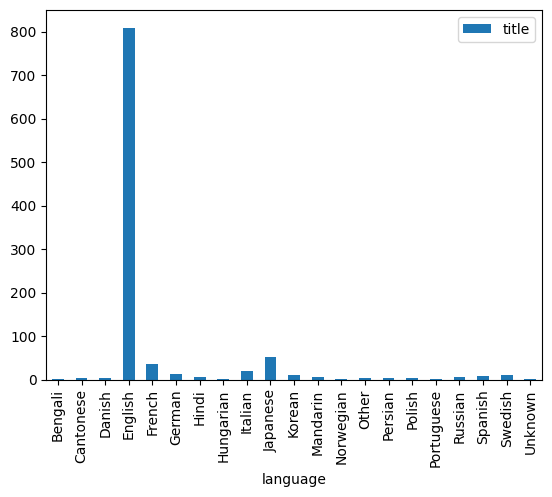

In [10]:
df.groupby(['language']).count().plot(y='title',kind='bar')

<Axes: xlabel='mpaa_rating'>

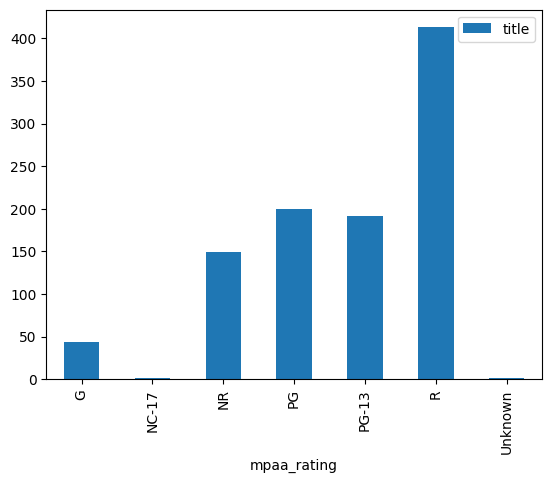

In [11]:
df.groupby(['mpaa_rating']).count().plot(y='title',kind='bar')

<Axes: xlabel='decade'>

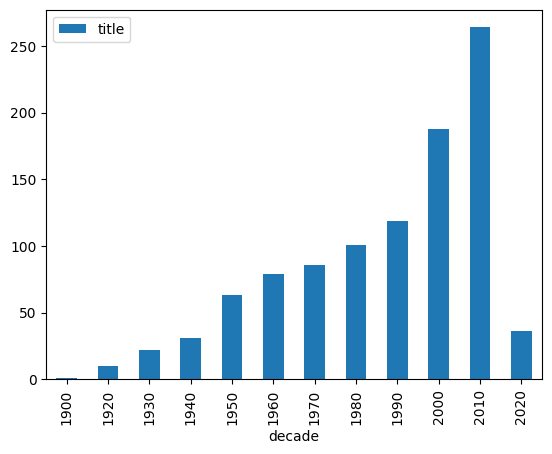

In [12]:
df.groupby(['decade']).count().plot(y='title',kind='bar')

In [13]:
df[df['title'].str.contains('Star Wars')]['title']

13     Star Wars: Episode V - The Empire Strikes Back
20                 Star Wars: Episode IV - A New Hope
48         Star Wars: Episode VI - Return of the Jedi
469                      Star Wars: The Force Awakens
630                      Rogue One: A Star Wars Story
Name: title, dtype: object

### Word Cloud

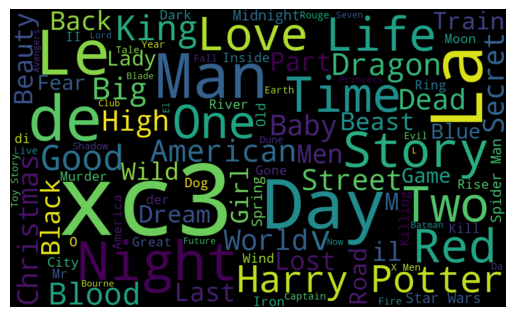

In [22]:
# Generate Combined Text
text = " ".join(txt for txt in df['title'])

# Create and generate a word cloud image:
wordcloud = WordCloud(max_font_size=200, max_words=100,width=1000,height=600).generate(text)

# Display the word cloud:
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.show()

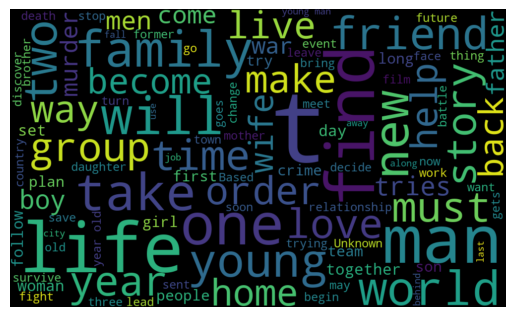

In [19]:
# Generate Combined Text
text = " ".join(txt for txt in df['plot'])

# Create and generate a word cloud image:
wordcloud = WordCloud(max_font_size=200, max_words=100,width=1000,height=600).generate(text)

# Display the word cloud:
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.show()